CNN，convolutional neural network

# 感受野 receptive field

感受野是指当前特征图里的每个特征是由原始多大区域的像素参与运算得到的

$R_l = R_{l-1} + (k_l-1) \cdot J_{l-1}$

\* 其中，k为kernel size，s为步长stride，$R_0=1, J_0=1, J_l=J_{l-1} \cdot s_l$

随着卷积不断进行，生成的特征图越来越小，感受野却越来越大。浅层网络发现局部细节特征，深层网络发现更加宏观的整体特征

# Padding

- 经过卷积后，新的特征图会变小，可能小到不能继续进行卷积操作；卷积操作会对图片中央的像素多次计算，边缘像素计算的次数较少
- padding：在图片周围添加全0的像素（相当于给原始图片周围加了一圈黑边）

# 生成特征图的尺寸计算

- input size：$W_{in}$，$H_{in}$
- kernal size：K
- padding：P，=> 使图的尺寸实际增加 2P
- stride：S，=> 除以步长时可能除不尽，需要向下取整
- output size：$
W_{out} = 1 + \lfloor \frac{W_{in}+2P-K}{S} \rfloor \quad
H_{out} = 1 + \lfloor \frac{H_{in}+2P-K}{S} \rfloor$

# 池化 Pooling

- 一般跟在一个或多个卷积层之后；
- 本质是进行下采样
- 减少特征图的大小；过滤一些干扰信息；局部平移不变性；
- 池化层一般步长和窗口大小相同，不重叠；一般不设置padding；
- 多channel：卷积时，卷积核的通道数需要与输入的通道数一样，输出只有一个通道，（如果要输出多通道，就需要设置多个卷积核）；池化时，每个通道独立进行，不改变输入的通道数。因为卷积有可学习的参数，而池化没有。
- 最大池化：聚焦关键特征，适合图像分类任务；
- 平均池化：对局部特征平滑处理，适合整体浓缩，最常用的是全局平均池化

## 1*1卷积

- 用于多通道，可以看成是一个全连接的神经元，一般只用于网络深层
- 用于改变特征图的通道数

## 全局平均池化层 global average pooling, GAP

- 对每个通道的整个空间维度进行平均运算，将 W\*H\*C 的特征图压缩为 1\*1\*C

## 1*1conv + GAP

- 1乘1卷积加GAP，可以完全省去最后的输出前的全连接层，大大减少模型参数
- 并且，可以让输入的图片是任意尺寸的。如果后面有全连接层，由于全连接层需要事先定义输入和输出参数大小，所以就定死了图片大小；而卷积对图片大小没有要求

在pytorch上实现卷积神经网络

In [1]:
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import random
import torch
from torchvision import transforms
import torch.nn as nn
import os

In [3]:
# 图片数据预处理
def verify_images(image_folder):
    classes = ["Cat", "Dog"]
    class_to_idx = {"Cat": 0, "Dog": 1}
    samples = []
    for cls_name in classes:
        cls_dir = os.path.join(image_folder, cls_name)
        for filename in os.listdir(cls_dir):
            if not filename.lower().endswith(('.jpg', 'jpeg', 'png')):
                continue
            path = os.path.join(cls_dir, filename)
            try:
                with Image.open(path) as img:
                    img.verify()
                samples.append((path, class_to_idx[cls_name]))
            except Exception:
                print(f"Warning: {cls_name} not found in {path}")
    return samples


# 定义数据集
class ImageDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform  # torchvision.transforms模块下的Transform对象，是对图像的一个或一系列操作，常用于调整图片大小、将图片转化为tensor、对图片进行归一化等操作

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        with Image.open(path) as img:
            img = img.convert("RGB")    # 统一转化为 RGB 三通道格式
            if self.transform:
                img = self.transform(img)
        return img, label


# 定义CNN网络
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 1*1 卷积
            nn.Conv2d(in_channels=128, out_channels=1, kernel_size=1, stride=1, padding=0),
            # 全局平均池化. 固定输出尺寸，e自动计算kernal size和strid
            nn.AdaptiveAvgPool2d(output_size=(1, 1)),   # 二分类只需要输出一个特征
            nn.Flatten(),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


# 验证集上正确率
def evaluate(model, test_dataloader):
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            inputs = inputs.to(DEVICE)
            labels = labels.float().unsqueeze(1).to(DEVICE)

            outputs = model(inputs)
            preds = (outputs > 0.5).float()
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    return val_acc



if __name__ == "__main__":
    DATA_DIR = "D:/agent/torch/data/archive/PetImages"
    BATCH_SIZE = 128
    IMG_SIZE = 128
    EPOCHS = 10
    LR = 0.001
    PRINT_STEP = 100
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    all_samples = verify_images(DATA_DIR)
    random.seed(42)
    random.shuffle(all_samples)
    train_samples = all_samples[:int(len(all_samples) * 0.8)]
    valid_samples  = all_samples[int(len(all_samples) * 0.8):]

    # 定义对图片进行一系列操作的 transform 对象
    data_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # 在ImageNet训练集中超过100万张图统计得到的
    ])

    # 定义数据集
    train_dataset = ImageDataset(train_samples, data_transform)
    valid_dataset = ImageDataset(valid_samples, data_transform)
    train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    valid_dataloader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # 定义模型、损失函数、优化器
    model = CNNModel().to(DEVICE)
    criterion = nn.BCELoss()    # 二分类交叉熵损失
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    # 训练循环
    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch + 1}/{EPOCHS}")
        model.train()
        running_loss = 0.0

        for step, (inputs, labels) in enumerate(train_dataloader):
            inputs = inputs.to(DEVICE)
            labels = labels.float().unsqueeze(1).to(DEVICE)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

            if (step+1) % PRINT_STEP == 0:
                avg_loss = running_loss / PRINT_STEP
                print(f"    Step {step+1}, Loss: {avg_loss:.4f}")
                running_loss = 0.0

        val_acc = evaluate(model, valid_dataloader)
        print(f"\nValidation Accuracy after epoch {epoch+1}: {val_acc:.4f}")


Epoch 1/10
    Step 100, Loss: 0.6652

Validation Accuracy after epoch 1: 0.6250

Epoch 2/10
    Step 100, Loss: 0.6179

Validation Accuracy after epoch 2: 0.6964

Epoch 3/10
    Step 100, Loss: 0.5653

Validation Accuracy after epoch 3: 0.7486

Epoch 4/10
    Step 100, Loss: 0.5372

Validation Accuracy after epoch 4: 0.7564

Epoch 5/10
    Step 100, Loss: 0.5101

Validation Accuracy after epoch 5: 0.7758

Epoch 6/10
    Step 100, Loss: 0.4953

Validation Accuracy after epoch 6: 0.7866

Epoch 7/10
    Step 100, Loss: 0.4795

Validation Accuracy after epoch 7: 0.7774

Epoch 8/10
    Step 100, Loss: 0.4422

Validation Accuracy after epoch 8: 0.8124

Epoch 9/10
    Step 100, Loss: 0.4199

Validation Accuracy after epoch 9: 0.8296

Epoch 10/10
    Step 100, Loss: 0.4042

Validation Accuracy after epoch 10: 0.8250


# 图像增强

通过一系列变换，在保持图像语义不变的前提下，生成多样化的新图像数据。
- 几何变换
- 颜色变换
- 噪声与模糊
- 遮罩
- 其他技术

In [17]:
import matplotlib.pyplot as plt
import numpy as np

In [7]:
# 定义函数，对图片应用Transform对象的操作
def imshow(img_path, transform):
    """
    function to show data augmentation
    :param img_path: path of the image
    :param transform: data augmentation technique to apply
    :return:
    """
    img = Image.open(img_path)
    fig, ax = plt.subplots(1, 2, figsize=(15, 4))
    ax[0].set_title(f"Original Image{img.size}")
    ax[0].imshow(img)
    img = transform(img)
    ax[1].set_title(f"Transformed Image{img.size}")
    ax[1].imshow(img)
    plt.show()

几何变换

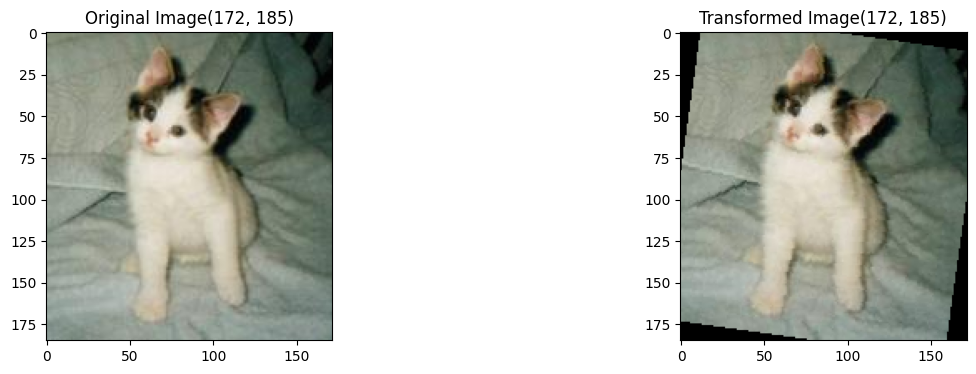

In [8]:
# -30~30度随机旋转
path = "D:/agent/torch/data/archive/PetImages/Cat/6039.jpg"
transform = transforms.RandomRotation(degrees=30)
imshow(path, transform)

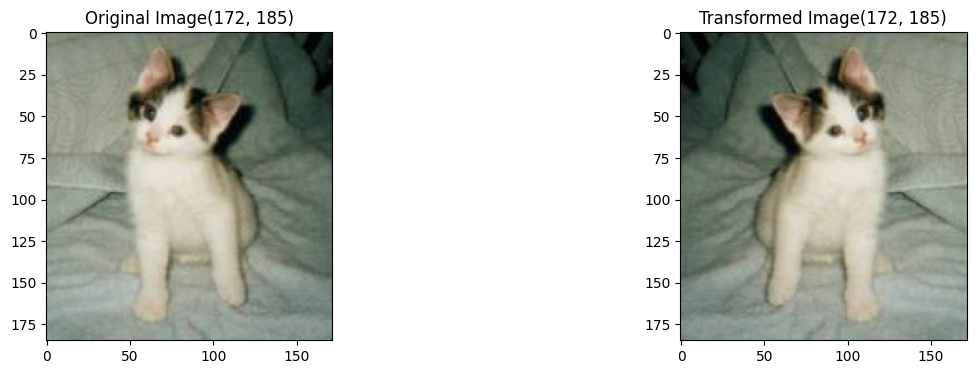

In [9]:
# 水平翻转
transform = transforms.RandomHorizontalFlip(p=1.0)    # p=1.0 表示总是翻转，p是翻转的概率
imshow(path, transform)

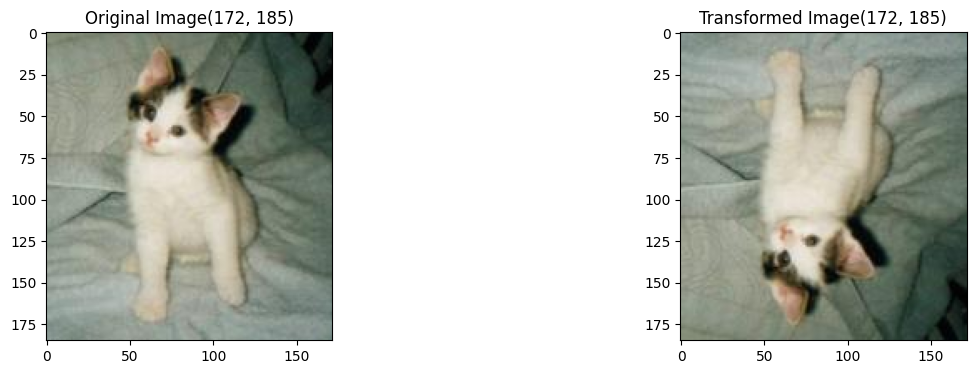

In [10]:
# 垂直翻转
transform = transforms.RandomVerticalFlip(p=1.0)
imshow(path, transform)

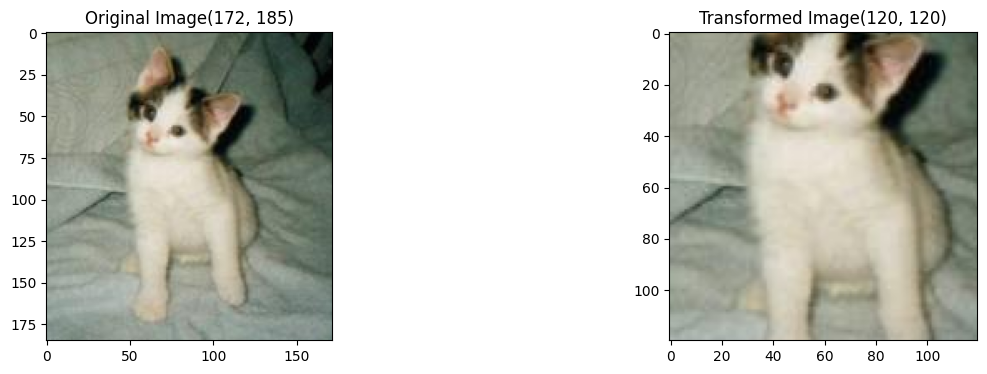

In [11]:
# 随机局部裁剪
transform = transforms.RandomCrop(size=(120,120))   # Resize() 是缩放整张图
imshow(path, transform)

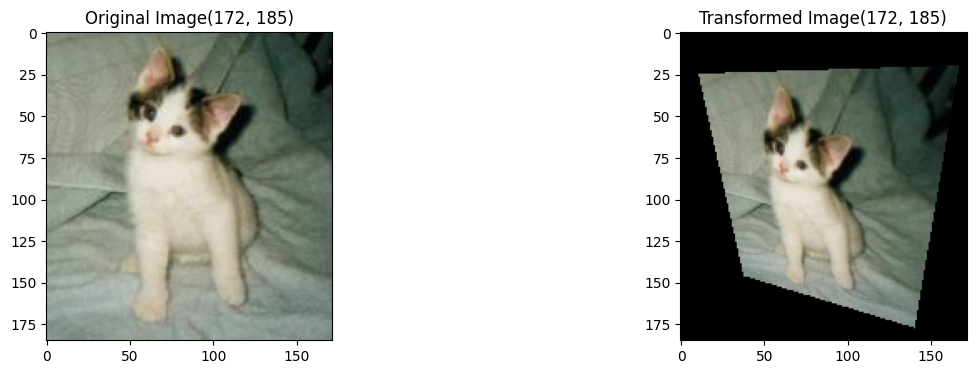

In [13]:
# 透视变换，模拟图像拍摄时角度扭曲
transform = transforms.RandomPerspective(
    distortion_scale=0.5,   # 四个角可以偏移的最大程度,控制变形强度，0-1，越大越扭曲
    p=1.0,   # 应用该变换的概率
    interpolation=transforms.InterpolationMode.BILINEAR
)
imshow(path, transform)

颜色变换

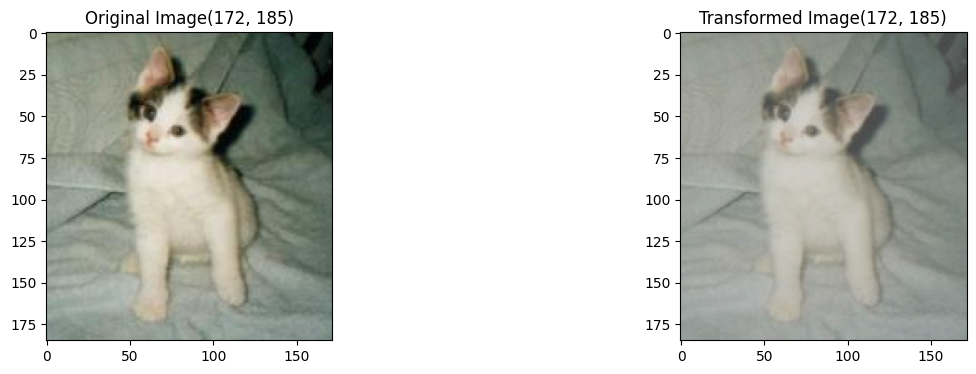

In [14]:
transform = transforms.ColorJitter(
    brightness=0.5, # 亮暗程度，亮度因子在[1 - x, 1 + x] 中随机选一个
    contrast=0.5,   # 对比度，[1 - x, 1 + x]
    saturation=0.5, # 鲜艳程度，[1 - x, 1 + x]
    hue=0.1         # 色调，[-x, x]
)
imshow(path, transform)

模糊

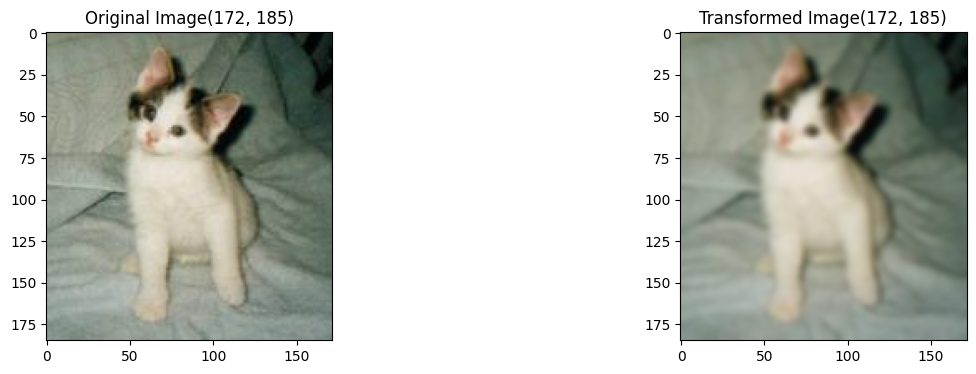

In [15]:
# 高斯模糊
transform = transforms.GaussianBlur(
    kernel_size=5,      # 高斯模糊卷积核大小，必须是奇数，越大越模糊
    sigma=(0.1, 3.0)    # 高斯核标准差范围，越大越模糊
)
imshow(path, transform)

遮罩 Cutout

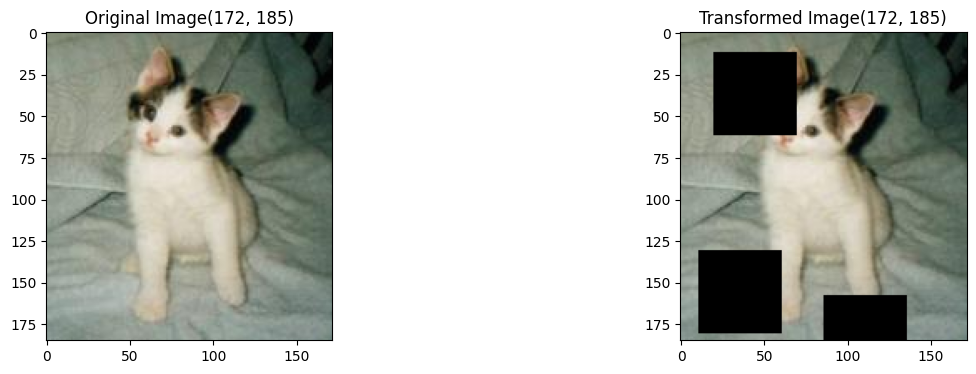

In [19]:
# cutout和dropout类似，在训练图像山随机遮挡一个或多个连续的方形区域

def cutout_pil_multi(image, mask_size=50, num_masks=3):
    """
    对图像应用多个 cutout 遮挡块
    :param image: PIL.Image 对象
    :param mask_size: 每个遮挡块的大小
    :param num_masks: 遮挡块数量
    :return:
    """
    image_np = np.array(image).copy()
    h, w = image_np.shape[0], image_np.shape[1]

    for _ in range(num_masks):
        y = random.randint(0, h - 1)
        x = random.randint(0, w - 1)

        y1 = max(0, y - mask_size // 2)
        y2 = min(h, y + mask_size // 2)
        x1 = max(0, x - mask_size // 2)
        x2 = min(w, x + mask_size // 2)

        # 遮挡区域设置为黑色
        image_np[y1:y2, x1:x2, :] = 0

    return Image.fromarray(image_np)

imshow(path, cutout_pil_multi)

# 目标检测 object detection

- 标注数据：Ground Truth
    - $P_c, x, y, h, w, P_{car}, P_{ped}, P_{bic}$
    - $P_c$图片中是否包含目标，$P_{car}, P_{ped}, P_{bic}$图片中是否包含汽车、行人、自行车，(x,y)目标中心点坐标，(h,w)目标高和宽

- R-CNN：regions with convolutional neural network
    - 第一阶段获得目标可能存在的区域；
    - 第二阶段对目标区域运行卷积神经网络进行进行分类和定位；
    - 分了两个阶段，速度相对较慢，但是精度比较高
- YOLO：you only look once
    - 将原始图片划分为多个cell，每个目标的中心点落在哪个cell，就由哪个cell负责预测。因为特征图上每个像素的感受野大于对应的cell，所以即使目标有一部分超出它所在cell的范围，特征图里还是可以进行预测每个目标的位置和大小

# 语义分割 semantic segmentation

- 本质是对原始照片每个像素进行多分类。
- CNN对图片进行下采样，得到高级语义特征，然后利用**转置卷积**将特征图上采样到原始图片大小，再对图像每个像素进行分类

---

# U-Net：

- 下采样提语义（encoder）+ 上采样还原空间（decoder）+ 同层跳跃连接（skip connections）
    - encoder：类似传统CNN，用于提取图像特征。若干个卷积层和maxpool组成，每次下采样都减小特征图的空间分辨率、增大通道数，捕捉更深层次的语义信息；
    - decoder：上采样逐步恢复图像的空间分辨率，UpConv → 拼接 → Conv → Conv；
    - skip connections：每个上采用步骤中，把encoder中对应层的特征图与decoder当前的特征图进行拼接concat。保留了低层的空间信息，避免了图像细节信息在下采样过程中丢失
    - 输出：1*1卷积，将多通道特征图映射为类别数通道，然后softmax分类

U-Net的实现

In [1]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    """两个连续的 3*3Conv(padding=1) + BN + ReLU"""
    def __init__(self, in_ch, out_ch):
        super(DoubleConv, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.double_conv(x)


class UNet(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(UNet, self).__init__()
        # 编码路径
        self.conv1 = DoubleConv(in_ch, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv5 = DoubleConv(512, 1024)  # 最低层

        # 解码路径
        self.up6 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)   # 上采用
        self.conv6 = DoubleConv(1024, 512)  # concat拼接后通道数变为 512+512=1024

        self.up7 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv7 = DoubleConv(512, 256)

        self.up8 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv8 = DoubleConv(256, 128)

        self.up9 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv9 = DoubleConv(128, 64)

        self.final_conv = nn.Conv2d(64, out_ch, kernel_size=1)

    def forward(self, x):
        # 编码
        c1 = self.conv1(x)      # c1: [B, 64, H, W]
        p1 = self.pool1(c1)     # p1: [B, 64, H/2, W/2]
        c2 = self.conv2(p1)     # c2: [B, 128, H/2, W/2]
        p2 = self.pool2(c2)     # p2: [B. 128, H/4, W/4]
        c3 = self.conv3(p2)     # c3: [B, 256, H/4, W/4]
        p3 = self.pool3(c3)     # p3: [B, 256, H/8, W/8]
        c4 = self.conv4(p3)     # c4: [B, 512, H/8, W/8]
        p4 = self.pool4(c4)     # p4: [B, 512, H/16, W/16]
        c5 = self.conv5(p4)     # c5: [B, 1024, H/16, W/16]

        # 解码：第 1 级上采样
        u6 = self.up6(c5)       # u6: [B, 512, H/8, W/8]
        # 直接拼接 c4 和 u6
        u6 = torch.cat([c4, u6], dim=1) # 拼接后：[B, 1024, H/8, W/8]
        c6 = self.conv6(u6)     # c6: [B, 512, H/8, W/8]

        # 解码：第 2 级
        u7 = self.up7(c6)       # u7: [B, 256, H/4, W/4]
        u7 = torch.cat([c3, u7], dim=1) # [B, 512, H/4, W/4]
        c7 = self.conv7(u7)     # c7: [B, 256, H/4, W/4]

        # 解码：第 3 级
        u8 = self.up8(c7)       # u8: [B, 128, H/2, W/2]
        u8 = torch.cat([c2, u8], dim=1) # [B, 256, H/2, W/2]
        c8 = self.conv8(u8)     # c8: [B, 128, H/2, W/2]

        # 解码：第 4 级
        u9 = self.up9(c8)       # u9: [B, 64, H, W]
        u9 = torch.cat([c1, u9], dim=1) # [B, 128, H, W]
        c9 = self.conv9(u9)     # c9: [B, 64, H, W]

        # 最后一层：1*1卷积，得到最终预测
        out = self.final_conv(c9)   # [B, out_ch, H, W]
        return out